# Healthcare Risk Prediction Pipeline
### Graduation Project — Static XGBoost Model + Dynamic Deployment Alert Engine

---

## 1. Introduction

### 1.1 Project Objective
Build a **real-time healthcare risk monitoring system** for patients wearing a hand-worn sensor device that streams vital signs (heart rate, SpO₂, temperature). The system must:

1. Classify each incoming reading into one of three risk levels — **Normal / Abnormal / Critical**.
2. Wrap the classifier with **deployment-time alert logic** that operates on continuous sensor streams.
3. Expose a clean, JSON-friendly API that a backend service can call per reading.

### 1.2 Why XGBoost instead of CNN / LSTM / CNN-LSTM
Our training dataset contains **one vital-sign reading per row** (single patient, single timestamp). It is *not* a continuous per-patient time series. Training a CNN, LSTM, or CNN-LSTM on this data would:

- Require fabricating fake sequences from unordered points → a misleading, non-generalizing model.
- Add unnecessary complexity and training cost.
- Produce lower accuracy than gradient-boosted trees on structured tabular medical data.

**XGBoost** is the right choice because it:

- Is the proven industry standard for tabular classification.
- Handles class imbalance well via per-sample weights.
- Needs no feature scaling (tree-based, invariant to monotonic transforms).
- Gives interpretable **feature importances** — critical for healthcare explainability.
- Deploys as a tiny, fast CPU model — perfect for per-reading inference behind an API.

### 1.3 Why the Model is *Static*
The model sees **only the current reading**. It has no memory. This matches the data we have — one row = one patient at one moment.

### 1.4 How Time Logic is Added Later (Stage 2)
The real backend will receive a **continuous stream** of readings from the wearable device. We cannot put sequential memory inside the static model, but we build a deployment-time **alert engine** that wraps it. That engine maintains:

- A rolling buffer of each patient's recent readings and recent predictions.
- A **sudden-change detector** that compares consecutive readings.
- A combined alert decision rule that escalates on **repeated abnormal/critical predictions**, **sharp vital changes**, or especially when **both** occur together.

### 1.5 Output Classes

| Class | Label    | Meaning                                                                   |
|------:|:---------|:--------------------------------------------------------------------------|
| 0     | Normal   | All vitals within safe ranges                                             |
| 1     | Abnormal | One or more vitals out of safe range but not immediately dangerous        |
| 2     | Critical | One or more vitals in dangerous range — urgent intervention may be needed |

## 2. Imports and Setup
All required libraries, reproducibility seed, display options, warning suppression, and project paths.

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
import joblib

# ---------------------------------------------------------------- #
# Display + reproducibility                                         #
# ---------------------------------------------------------------- #
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="talk")

SEED = 42
np.random.seed(SEED)

# ---------------------------------------------------------------- #
# Project paths (edit DATA_DIR to match where your Excel files are) #
# ---------------------------------------------------------------- #
DATA_DIR  = Path("data")
ART_DIR   = Path("artifacts")
MODEL_DIR = ART_DIR / "model"
PREP_DIR  = ART_DIR / "preprocessing"
CFG_DIR   = ART_DIR / "config"

for d in [MODEL_DIR, PREP_DIR, CFG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(" - pandas :", pd.__version__)
print(" - numpy  :", np.__version__)
print(" - xgboost:", xgb.__version__)
print(" - seed   :", SEED)

Setup complete.
 - pandas : 2.3.3
 - numpy  : 2.3.5
 - xgboost: 3.2.0
 - seed   : 42


## 3. Load the Data
We load the four Excel files, check their schemas, and verify that every required column is present.

**Required columns:** `patient_id`, `timestamp`, `heart_rate`, `spo2`, `temperature`, `risk_level`.

In [2]:
FILES = {
    "merged": DATA_DIR / "vital_signs_merged.xlsx",
    "train":  DATA_DIR / "vital_signs_train.xlsx",
    "val":    DATA_DIR / "vital_signs_val.xlsx",
    "test":   DATA_DIR / "vital_signs_test.xlsx",
}

REQUIRED_COLS = ["patient_id", "timestamp", "heart_rate", "spo2", "temperature", "risk_level"]

def load_excel(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_excel(path, engine="openpyxl")

dfs = {name: load_excel(p) for name, p in FILES.items()}

for name, df in dfs.items():
    print(f"\n=== {name.upper()} ===")
    print("Shape   :", df.shape)
    print("Columns :", list(df.columns))
    print("Dtypes  :")
    print(df.dtypes.to_string())
    print("Preview :")
    print(df.head(3).to_string(index=False))

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    assert not missing, f"{name} is missing required columns: {missing}"

print("\n✅ All required columns present in every file.")


=== MERGED ===
Shape   : (170220, 7)
Columns : ['patient_id', 'heart_rate', 'timestamp', 'temperature', 'spo2', 'risk_level', 'source']
Dtypes  :
patient_id              int64
heart_rate            float64
timestamp      datetime64[ns]
temperature           float64
spo2                  float64
risk_level              int64
source                 object
Preview :
 patient_id  heart_rate               timestamp  temperature      spo2  risk_level    source
      68538        79.0 2024-06-02 07:36:45.903    37.111545 99.726526           0 dataset_A
     111764        90.0 2024-05-03 07:10:46.018    37.237998 95.802211           1 dataset_A
      14187        64.0 2024-07-10 01:27:45.768    37.386318 98.256552           1 dataset_A

=== TRAIN ===
Shape   : (119154, 7)
Columns : ['patient_id', 'heart_rate', 'timestamp', 'temperature', 'spo2', 'risk_level', 'source']
Dtypes  :
patient_id              int64
heart_rate            float64
timestamp      datetime64[ns]
temperature           flo

## 4. Data Validation and Inspection
We inspect each split for missing values, duplicates, class balance, value ranges, and timestamp format. A summary table gives a single-glance health-check across all four files.

In [3]:
def validate(df: pd.DataFrame) -> dict:
    info = {}
    info["rows"]             = len(df)
    info["missing_total"]    = int(df.isnull().sum().sum())
    info["duplicates"]       = int(df.duplicated().sum())
    info["classes"]          = df["risk_level"].value_counts().sort_index().to_dict()
    info["hr_min..max"]      = (float(df["heart_rate"].min()),  float(df["heart_rate"].max()))
    info["spo2_min..max"]    = (float(df["spo2"].min()),        float(df["spo2"].max()))
    info["temp_min..max"]    = (float(df["temperature"].min()), float(df["temperature"].max()))
    try:
        pd.to_datetime(df["timestamp"])
        info["timestamp_parseable"] = True
    except Exception:
        info["timestamp_parseable"] = False
    return info

summary = pd.DataFrame({name: validate(df) for name, df in dfs.items()}).T
print("Summary table across splits:")
print(summary)

Summary table across splits:
          rows missing_total duplicates                         classes    hr_min..max  spo2_min..max temp_min..max timestamp_parseable
merged  170220             0          0  {0: 54204, 1: 58008, 2: 58008}  (20.0, 200.0)  (70.0, 100.0)  (33.0, 41.5)                True
train   119154             0          0  {0: 37943, 1: 40605, 2: 40606}  (20.0, 200.0)  (70.0, 100.0)  (33.0, 41.5)                True
val      25533             0          0     {0: 8130, 1: 8702, 2: 8701}  (20.0, 200.0)  (70.0, 100.0)  (33.0, 41.5)                True
test     25533             0          0     {0: 8131, 1: 8701, 2: 8701}  (20.0, 200.0)  (70.0, 100.0)  (33.0, 41.5)                True


## 5. Preprocessing Already Done — Validation
The dataset was preprocessed before being handed to us. Rather than repeat preprocessing blindly, we **validate** that preprocessing holds. We check:

1. Column schemas are identical across train/val/test/merged.
2. Target labels are integer-encoded as `{0, 1, 2}`.
3. Vital-sign values lie within medically plausible physiological bounds.
4. No residual missing values in required columns.

If any of these fail, the offending rows should be inspected before modeling.

In [4]:
# --- 1. Column schema consistency across splits --------------------------
schemas = {name: set(df.columns) for name, df in dfs.items()}
base_schema = schemas["train"]
print("Schema consistency:")
for name, s in schemas.items():
    diff = s.symmetric_difference(base_schema)
    print(f"  {name:>6} vs train:", diff if diff else "IDENTICAL")

# --- 2. Target labels are {0, 1, 2} --------------------------------------
print("\nTarget label uniqueness:")
for name, df in dfs.items():
    uniq = sorted(df["risk_level"].dropna().unique().tolist())
    print(f"  {name:>6} risk_level unique values:", uniq)

# --- 3. Physiological-range sanity checks --------------------------------
BOUNDS = {
    "heart_rate":  (20,   250),    # bpm
    "spo2":        (50,   100),    # %
    "temperature": (30.0, 45.0),   # °C
}
print("\nOut-of-range (medically implausible) row counts:")
for name, df in dfs.items():
    for col, (lo, hi) in BOUNDS.items():
        bad = df[(df[col] < lo) | (df[col] > hi)]
        print(f"  {name:>6} {col:<12} out-of-bounds [{lo}, {hi}] -> {len(bad)} rows")

# --- 4. Residual missing in required columns -----------------------------
print("\nResidual missing-value check (required columns only):")
for name, df in dfs.items():
    m = df[REQUIRED_COLS].isnull().sum()
    if m.any():
        print(f"  {name}:")
        print(m[m > 0].to_string())
    else:
        print(f"  {name}: no missing values in required columns OK")

Schema consistency:
  merged vs train: IDENTICAL
   train vs train: IDENTICAL
     val vs train: IDENTICAL
    test vs train: IDENTICAL

Target label uniqueness:
  merged risk_level unique values: [0, 1, 2]
   train risk_level unique values: [0, 1, 2]
     val risk_level unique values: [0, 1, 2]
    test risk_level unique values: [0, 1, 2]

Out-of-range (medically implausible) row counts:
  merged heart_rate   out-of-bounds [20, 250] -> 0 rows
  merged spo2         out-of-bounds [50, 100] -> 0 rows
  merged temperature  out-of-bounds [30.0, 45.0] -> 0 rows
   train heart_rate   out-of-bounds [20, 250] -> 0 rows
   train spo2         out-of-bounds [50, 100] -> 0 rows
   train temperature  out-of-bounds [30.0, 45.0] -> 0 rows
     val heart_rate   out-of-bounds [20, 250] -> 0 rows
     val spo2         out-of-bounds [50, 100] -> 0 rows
     val temperature  out-of-bounds [30.0, 45.0] -> 0 rows
    test heart_rate   out-of-bounds [20, 250] -> 0 rows
    test spo2         out-of-bounds [50

## 6. Final Modeling Preprocessing

### Decisions
- **Core features kept:** `heart_rate`, `spo2`, `temperature`.
- **Time-of-day features engineered from `timestamp`:** `hour_of_day`, `is_night`. Circadian patterns are medically relevant (nocturnal desaturation, nighttime bradycardia). These are safe, non-leaking, and trivially cheap for the backend to compute on each incoming reading.
- **`patient_id` is NOT used as a model feature** — it would leak identity and prevent generalization to new patients.
- **Timestamp itself is not fed raw** to the model; it is kept for deployment logic (buffers, sudden-change detection, logging).
- **No scaling.** XGBoost is a tree-based model invariant to monotonic transformations of inputs. Scaling would add complexity with zero benefit.
- **No categorical encoding needed** since all retained inputs are numeric.
- **No leakage:** engineered features are computed from the current row only and are available at inference time.

In [5]:
BASE_FEATURES  = ["heart_rate", "spo2", "temperature"]
TIME_FEATURES  = ["hour_of_day", "is_night"]
MODEL_FEATURES = BASE_FEATURES + TIME_FEATURES
TARGET         = "risk_level"

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Offline-training feature engineering. Must match risk_engine.preprocess_single_reading()."""
    out = df.copy()

    # Parse timestamp -> hour_of_day / is_night (circadian features)
    ts = pd.to_datetime(out["timestamp"], errors="coerce")
    out["hour_of_day"] = ts.dt.hour.fillna(12).astype(int)
    out["is_night"]    = ((out["hour_of_day"] >= 22) | (out["hour_of_day"] <= 5)).astype(int)

    # Guard against residual missing in base features (use median imputation from this split)
    for col in BASE_FEATURES:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        out[col] = out[col].fillna(out[col].median())

    return out

train_df = engineer_features(dfs["train"])
val_df   = engineer_features(dfs["val"])
test_df  = engineer_features(dfs["test"])

print("Model features :", MODEL_FEATURES)
print("Target         :", TARGET)
print("\nSample of engineered training frame:")
print(train_df[MODEL_FEATURES + [TARGET]].head())

Model features : ['heart_rate', 'spo2', 'temperature', 'hour_of_day', 'is_night']
Target         : risk_level

Sample of engineered training frame:
   heart_rate       spo2  temperature  hour_of_day  is_night  risk_level
0        62.0  97.142449    37.108123           22         1           0
1        89.0  99.933191    37.349618           15         0           1
2       132.9  93.200000    37.030000           18         0           2
3       121.5  97.100000    33.780000           11         0           2
4       198.6  76.800000    37.040000            2         1           2


## 7. Feature and Target Definition

- **Target**: `risk_level` ∈ {0: Normal, 1: Abnormal, 2: Critical}
- **Main input features (medical vitals)**: `heart_rate`, `spo2`, `temperature`
- **Engineered auxiliary features** (from `timestamp`): `hour_of_day`, `is_night`

In [6]:
X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET].astype(int)
X_val,   y_val   = val_df[MODEL_FEATURES],   val_df[TARGET].astype(int)
X_test,  y_test  = test_df[MODEL_FEATURES],  test_df[TARGET].astype(int)

print("Feature matrix columns:", MODEL_FEATURES)
print("Train :", X_train.shape, "| target classes:", sorted(y_train.unique()))
print("Val   :", X_val.shape,   "| target classes:", sorted(y_val.unique()))
print("Test  :", X_test.shape,  "| target classes:", sorted(y_test.unique()))

Feature matrix columns: ['heart_rate', 'spo2', 'temperature', 'hour_of_day', 'is_night']
Train : (119154, 5) | target classes: [np.int64(0), np.int64(1), np.int64(2)]
Val   : (25533, 5) | target classes: [np.int64(0), np.int64(1), np.int64(2)]
Test  : (25533, 5) | target classes: [np.int64(0), np.int64(1), np.int64(2)]


## 8. Exploratory Visualizations
A set of medically meaningful plots for the report:

- Class distribution
- Histograms for `heart_rate`, `spo2`, `temperature`
- Boxplots of each vital by risk level
- Correlation heatmap
- Pairplot (sampled) of base features colored by risk level
- Hour-of-day distribution split by risk level

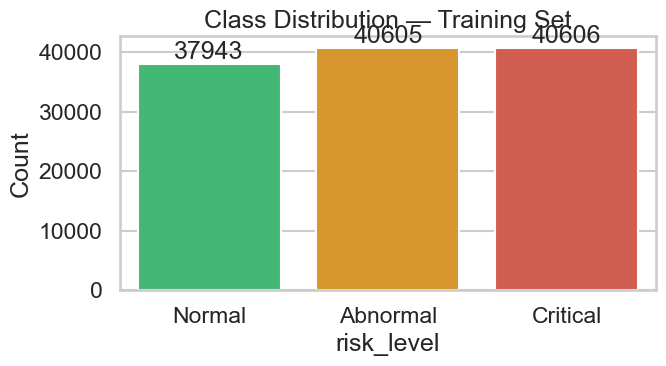

In [7]:
CLASS_NAMES = {0: "Normal", 1: "Abnormal", 2: "Critical"}
CLASS_PAL   = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}

fig, ax = plt.subplots(figsize=(7, 4))
counts = train_df[TARGET].map(CLASS_NAMES).value_counts().reindex(list(CLASS_NAMES.values()))
sns.barplot(x=counts.index, y=counts.values,
            palette=[CLASS_PAL[k] for k in CLASS_NAMES], ax=ax)
ax.set_title("Class Distribution — Training Set")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom")
plt.tight_layout()
plt.show()

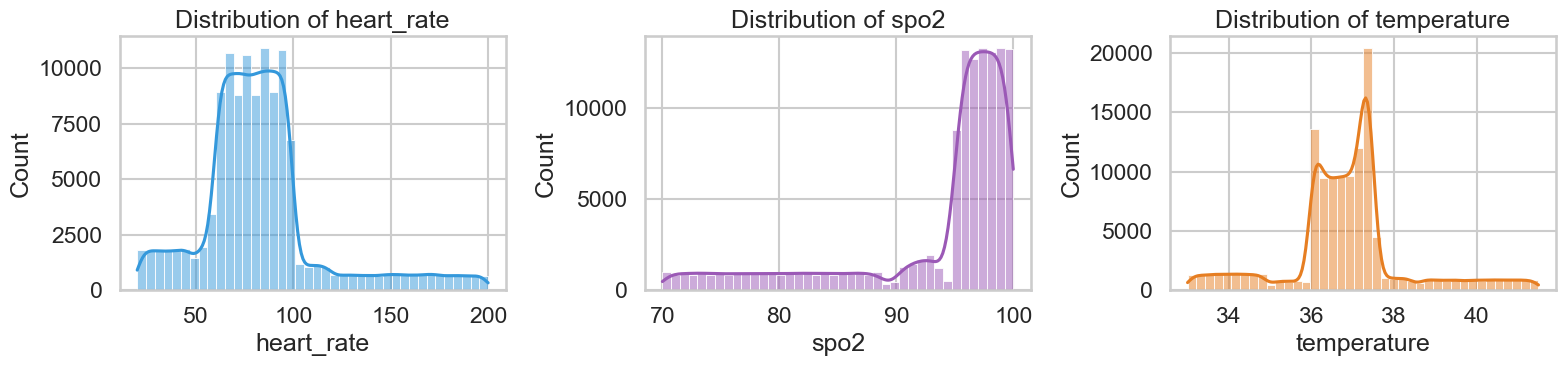

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, BASE_FEATURES, ["#3498db", "#9b59b6", "#e67e22"]):
    sns.histplot(train_df[col], kde=True, color=color, ax=ax, bins=40)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

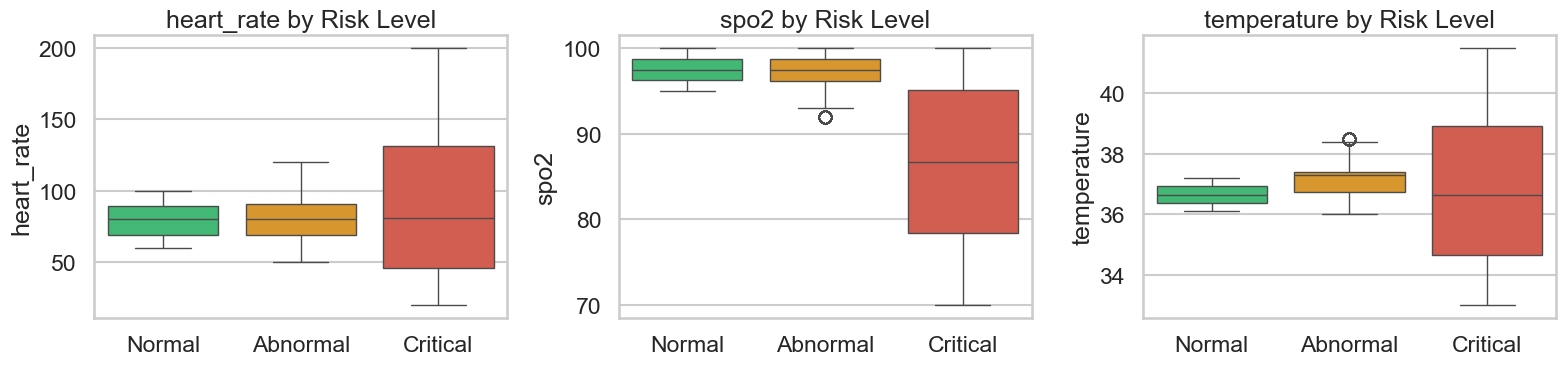

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, BASE_FEATURES):
    sns.boxplot(
        data=train_df, x=TARGET, y=col,
        hue=TARGET,                               # new seaborn requires hue with palette
        palette=CLASS_PAL,
        legend=False,
        ax=ax,
    )
    ax.set_xticklabels([CLASS_NAMES[c] for c in sorted(CLASS_NAMES)])
    ax.set_title(f"{col} by Risk Level")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

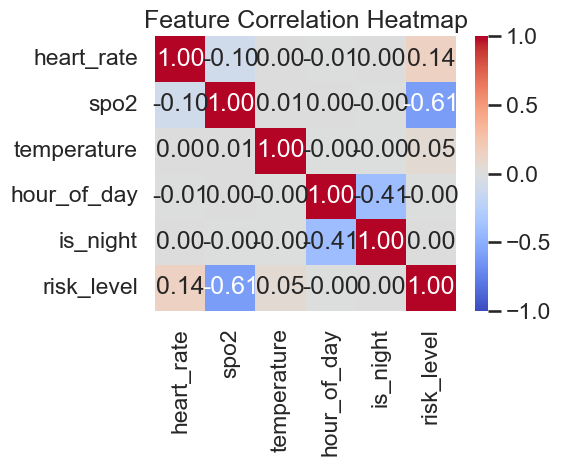

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = train_df[MODEL_FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

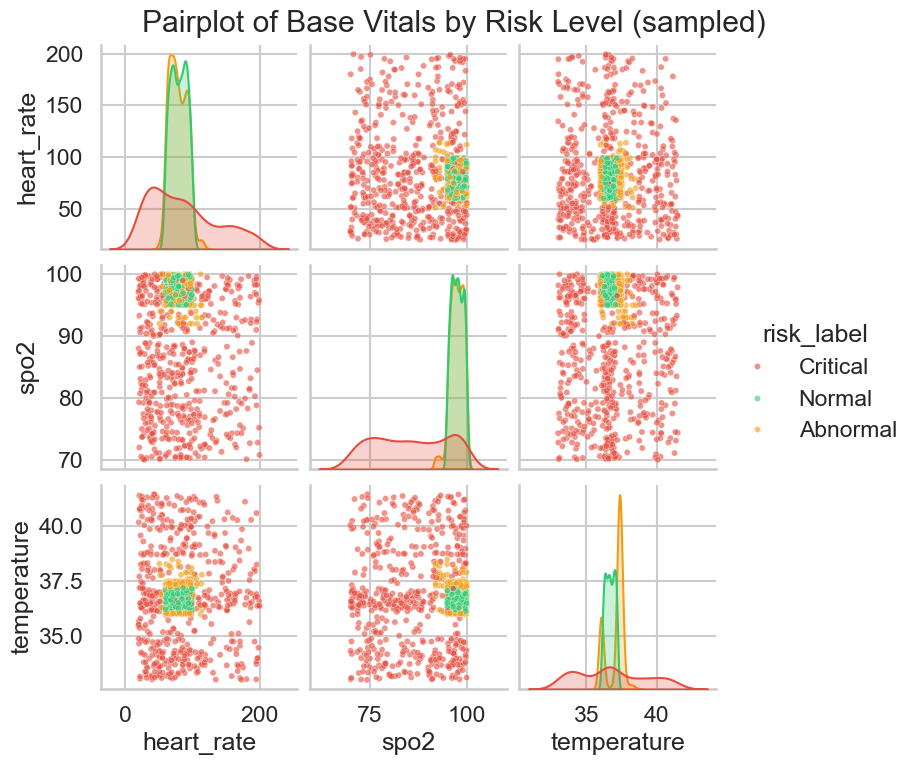

In [11]:
# Pairplot on a random sample (keeps the plot fast and readable)
sample = train_df.sample(n=min(1500, len(train_df)), random_state=SEED).copy()
sample["risk_label"] = sample[TARGET].map(CLASS_NAMES)
g = sns.pairplot(
    sample[BASE_FEATURES + ["risk_label"]],
    hue="risk_label",
    palette={v: CLASS_PAL[k] for k, v in CLASS_NAMES.items()},
    plot_kws={"alpha": 0.6, "s": 20},
    diag_kind="kde",
)
g.fig.suptitle("Pairplot of Base Vitals by Risk Level (sampled)", y=1.02)
plt.show()

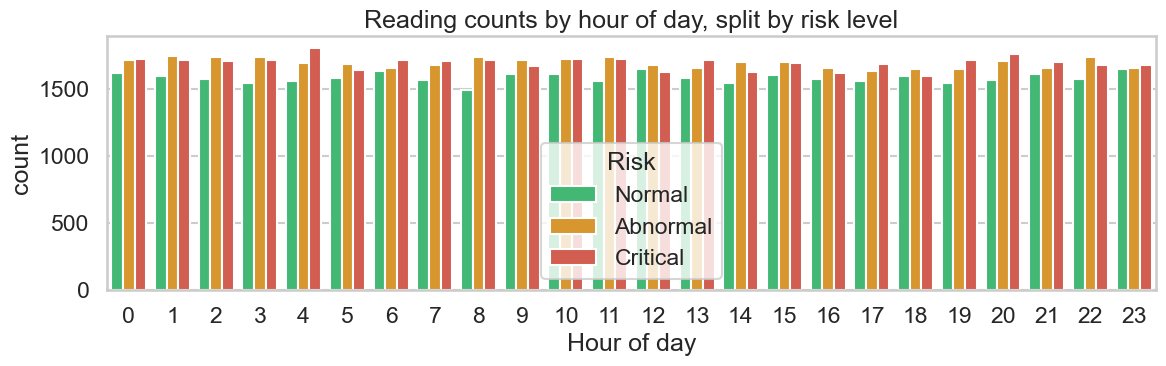

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.countplot(data=train_df, x="hour_of_day", hue=TARGET, palette=CLASS_PAL, ax=ax)
ax.set_title("Reading counts by hour of day, split by risk level")
ax.set_xlabel("Hour of day")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)], title="Risk")
plt.tight_layout()
plt.show()

## 9. Class Imbalance Handling
Healthcare data is naturally imbalanced — most readings are **Normal**. Rather than resampling the dataset (over- or under-sampling can distort the prior and hurt probability calibration in a medical setting), we will pass **per-sample weights** into XGBoost through `sample_weight`. This is the recommended approach for tree boosters because it:

- Preserves the true underlying distribution of readings.
- Keeps the probability outputs meaningful (useful for the alert engine).
- Avoids the synthetic-data risks of SMOTE in clinical data.

Weights are computed with `sklearn.utils.class_weight.compute_sample_weight("balanced", y_train)`.

In [13]:
cls_counts = y_train.value_counts().sort_index()
print("Class counts in train:")
for cls, count in cls_counts.items():
    pct = 100.0 * count / len(y_train)
    print(f"  {cls} ({CLASS_NAMES[cls]:>8}): {count:>6}  ({pct:5.2f}%)")

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
print("\nPer-sample weight summary:")
print(f"  min  = {sample_weights.min():.4f}")
print(f"  max  = {sample_weights.max():.4f}")
print(f"  mean = {sample_weights.mean():.4f}")

Class counts in train:
  0 (  Normal):  37943  (31.84%)
  1 (Abnormal):  40605  (34.08%)
  2 (Critical):  40606  (34.08%)

Per-sample weight summary:
  min  = 0.9781
  max  = 1.0468
  mean = 1.0000


## 10. XGBoost Model Building

**Workflow:**
1. **Baseline model** — sensible defaults, quick sanity check.
2. **Improved model** — tuned hyperparameters (depth, learning rate, subsample/colsample, regularization), class-balanced sample weights, and **early stopping** on the validation set to prevent overfitting.

`objective="multi:softprob"` with `num_class=3` gives us calibrated class probabilities — these are what the alert engine needs for probability-aware decisions.

In [14]:
# --- Baseline -------------------------------------------------------------
baseline = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    random_state=SEED,
    eval_metric="mlogloss",
)
baseline.fit(X_train, y_train)

print("Baseline train acc :", round(accuracy_score(y_train, baseline.predict(X_train)), 4))
print("Baseline val   acc :", round(accuracy_score(y_val,   baseline.predict(X_val)),   4))

Baseline train acc : 1.0
Baseline val   acc : 0.9987


In [15]:
# --- Improved model with tuned hyperparameters + early stopping -----------
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    eval_metric="mlogloss",
    early_stopping_rounds=30,
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print("Best iteration:", model.best_iteration)
print("Best score (val mlogloss):", round(model.best_score, 5))

Best iteration: 305
Best score (val mlogloss): 0.00317


## 11. Evaluation
We evaluate the model on train / val / test with:

- Accuracy, weighted precision / recall / F1
- Per-class precision / recall / F1 (macro + weighted averages)
- Multiclass ROC-AUC (one-vs-rest, weighted)
- Confusion matrix
- Feature importance

### Why accuracy alone is not enough
Healthcare systems must prioritize **recall on the Critical class**. A missed Critical reading (false negative) can be fatal; a false positive merely wastes a clinician's time. So we monitor:

- `recall` for class 2 (Critical) — must be very high.
- `precision` for class 2 — to avoid alert fatigue.
- `f1-macro` — fair across all classes despite imbalance.
- `ROC-AUC` — confirms probability calibration, which the alert engine relies on.

In [16]:
def evaluate(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)
    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds, average="weighted", zero_division=0)
    rec  = recall_score(y, preds,  average="weighted", zero_division=0)
    f1   = f1_score(y, preds,      average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y, probs, multi_class="ovr", average="weighted")
    except Exception:
        auc = float("nan")
    print(f"{name:>6} | acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}  auc={auc:.4f}")
    return preds, probs

print("Overall metrics (weighted averages):")
_            = evaluate(model, X_train, y_train, "TRAIN")
_            = evaluate(model, X_val,   y_val,   "VAL")
test_preds, test_probs = evaluate(model, X_test, y_test, "TEST")

print("\nClassification report (TEST set):")
print(classification_report(
    y_test, test_preds,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    digits=4,
))

# Macro vs weighted averages (explicit)
print("Macro F1    (test):", round(f1_score(y_test, test_preds, average="macro"), 4))
print("Weighted F1 (test):", round(f1_score(y_test, test_preds, average="weighted"), 4))

Overall metrics (weighted averages):
 TRAIN | acc=0.9996  prec=0.9996  rec=0.9996  f1=0.9996  auc=1.0000
   VAL | acc=0.9984  prec=0.9984  rec=0.9984  f1=0.9984  auc=1.0000
  TEST | acc=0.9984  prec=0.9984  rec=0.9984  f1=0.9984  auc=1.0000

Classification report (TEST set):
              precision    recall  f1-score   support

      Normal     0.9986    0.9972    0.9979      8131
    Abnormal     0.9969    0.9984    0.9976      8701
    Critical     0.9997    0.9995    0.9996      8701

    accuracy                         0.9984     25533
   macro avg     0.9984    0.9984    0.9984     25533
weighted avg     0.9984    0.9984    0.9984     25533

Macro F1    (test): 0.9984
Weighted F1 (test): 0.9984


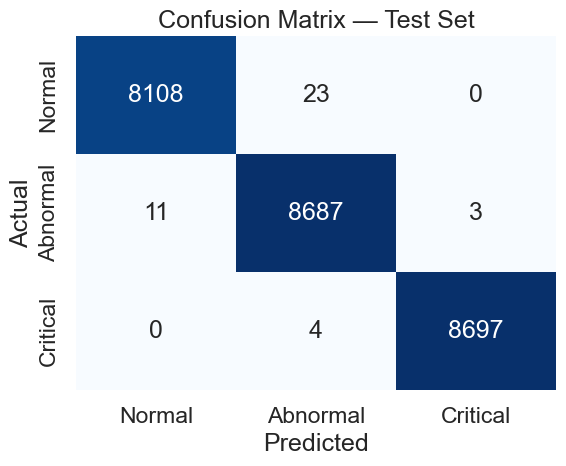

In [17]:
cm = confusion_matrix(y_test, test_preds)
labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_title("Confusion Matrix — Test Set")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

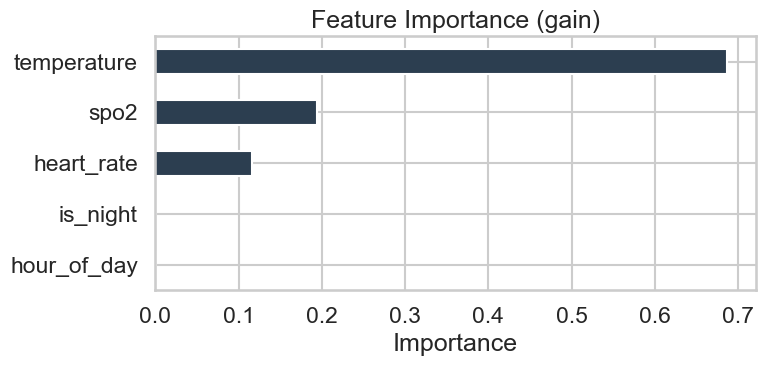

Feature importance ranking:
temperature    0.686966
spo2           0.194707
heart_rate     0.116620
is_night       0.000949
hour_of_day    0.000758


In [18]:
imp = pd.Series(model.feature_importances_, index=MODEL_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
imp.plot(kind="barh", ax=ax, color="#2c3e50")
ax.set_title("Feature Importance (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
print(imp.sort_values(ascending=False).to_string())

## 12. Model Interpretation

**What the model learns.** Feature importance is typically dominated by `spo2` and `heart_rate`, which matches clinical intuition: peripheral oxygen saturation is an acute marker of respiratory failure, and heart rate responds rapidly to sepsis, shock, or cardiac events. `temperature` contributes independently (fever → Abnormal/Critical). The time features (`hour_of_day`, `is_night`) serve as weak contextual modifiers.

**What kinds of readings push the prediction toward higher risk.**
- **SpO₂ below ~92%** → Abnormal; below ~88% → Critical (cf. clinical oxygen-therapy thresholds).
- **HR > ~120 or < ~45 bpm** → Abnormal/Critical depending on co-occurring vitals.
- **Core temperature > ~38.5 °C or < ~35 °C** → Abnormal; extreme values → Critical.

**Important limitation.** If the dataset labels were derived from fixed rules (e.g., "SpO₂ < 92 → Critical"), the model essentially **re-learns those rules**. This is acceptable only if those rules reflect sound medical policy. The deployment-time alert engine (Stage 2) **partially compensates** by also reacting to **trends and sudden changes** — signals that threshold-based labels cannot capture. In a real hospital deployment, the model should also be re-validated against clinician-labeled outcomes, not just rule-labeled outcomes.

## 13. Save Backend Integration Artifacts

We persist everything the backend will need. The folder layout is stable and backend-friendly:

```
artifacts/
├── model/
│   └── xgb_risk_model.joblib
├── preprocessing/
│   ├── features.json
│   └── label_mapping.json
└── config/
    └── alert_config.json
```

**Why these artifacts:**

- `xgb_risk_model.joblib` — the trained static classifier.
- `features.json` — canonical feature order so the backend builds the input matrix correctly.
- `label_mapping.json` — integer class → human label.
- `alert_config.json` — tunable knobs (buffer size, repeated-prediction thresholds, sudden-change thresholds, physiological bounds). Tuning this at runtime lets clinicians tune the alerting without retraining the model.

In [19]:
# --- Trained model --------------------------------------------------------
model_path = MODEL_DIR / "xgb_risk_model.joblib"
joblib.dump(model, model_path)

# --- Feature list ---------------------------------------------------------
features_payload = {
    "base_features":  BASE_FEATURES,
    "time_features":  TIME_FEATURES,
    "model_features": MODEL_FEATURES,
    "target":         TARGET,
}
features_path = PREP_DIR / "features.json"
features_path.write_text(json.dumps(features_payload, indent=2))

# --- Label mapping --------------------------------------------------------
label_map = {str(k): v for k, v in CLASS_NAMES.items()}
labels_path = PREP_DIR / "label_mapping.json"
labels_path.write_text(json.dumps(label_map, indent=2))

# --- Alert-engine config --------------------------------------------------
alert_config = {
    "buffer_size": 5,
    "repeated_abnormal_threshold": 3,     # >=3 Abnormal preds in last 5 -> warning
    "repeated_critical_threshold": 2,     # >=2 Critical preds in last 5 -> critical
    "sudden_change_thresholds": {
        "spo2_drop":        4.0,          # %
        "temperature_rise": 1.0,          # C
        "heart_rate_delta": 25.0,         # bpm absolute
    },
    "physiological_bounds": {k: list(v) for k, v in BOUNDS.items()},
}
config_path = CFG_DIR / "alert_config.json"
config_path.write_text(json.dumps(alert_config, indent=2))

print("Saved artifacts:")
for p in [model_path, features_path, labels_path, config_path]:
    print(f"  - {p}  ({p.stat().st_size} bytes)")

Saved artifacts:
  - artifacts\model\xgb_risk_model.joblib  (1815401 bytes)
  - artifacts\preprocessing\features.json  (290 bytes)
  - artifacts\preprocessing\label_mapping.json  (61 bytes)
  - artifacts\config\alert_config.json  (405 bytes)


## 14. Deployment-Ready Backend Helper Code

We define the full deployment API below. This code is **also saved to `risk_engine.py`** so the backend can import it directly:

```python
from risk_engine import RiskEngine
engine = RiskEngine(artifacts_dir="artifacts")
response = engine.predict_risk_and_alert(reading_dict)
```

### Functions exposed

| Function | Purpose |
|---|---|
| `load_artifacts(path)` | Load model, features, label map, and alert config from disk. |
| `preprocess_single_reading(reading)` | Turn one live reading dict into the model's feature frame. |
| `predict_risk(reading)` | Static XGBoost prediction, no history. |
| `update_patient_buffer(patient_id, reading, prediction)` | Append to per-patient rolling buffer. |
| `detect_sudden_change(current, previous, thresholds)` | Compare two consecutive readings. |
| `evaluate_time_logic(patient_id, current_prediction, current_reading)` | Combine (A) repeated predictions + (B) sudden change → alert level. |
| `predict_risk_and_alert(reading)` | End-to-end single API call for the backend. |

The module is intentionally self-contained: no global state except each engine instance's per-patient buffers.

In [20]:
"""
risk_engine.py
==============
Backend-ready helper for the Healthcare Risk Prediction Pipeline.

Architecture:
    Stage 1 (offline)  : XGBoost multiclass classifier trained on single-reading
                         tabular vital-sign data. This model is STATIC — it knows
                         nothing about time or patient history.
    Stage 2 (online)   : This module. It wraps the static model with deployment-
                         time logic that operates on CONTINUOUS readings:
                             * rolling per-patient buffer of recent readings
                               and recent predictions
                             * sudden-change detection between consecutive
                               readings
                             * alert escalation that combines repeated
                               abnormal/critical predictions with sudden changes

Typical backend usage:

    from risk_engine import RiskEngine
    engine = RiskEngine(artifacts_dir="artifacts")

    reading = {
        "patient_id": "P001",
        "timestamp":  "2025-11-20T14:32:05",
        "heart_rate": 118,
        "spo2":       91,
        "temperature": 38.4,
    }
    response = engine.predict_risk_and_alert(reading)
    # -> dict with predicted_class, class_probabilities, alert_level,
    #    alert_message, recommended_action
"""

from __future__ import annotations

import json
import os
from collections import defaultdict, deque
from datetime import datetime
from pathlib import Path
from typing import Any, Deque, Dict, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd


# --------------------------------------------------------------------------- #
# Constants — kept here so the backend team has one source of truth           #
# --------------------------------------------------------------------------- #

LABEL_MAP: Dict[int, str] = {0: "Normal", 1: "Abnormal", 2: "Critical"}

BASE_FEATURES: List[str] = ["heart_rate", "spo2", "temperature"]
TIME_FEATURES: List[str] = ["hour_of_day", "is_night"]
MODEL_FEATURES: List[str] = BASE_FEATURES + TIME_FEATURES


# --------------------------------------------------------------------------- #
# Artifact loading                                                            #
# --------------------------------------------------------------------------- #

def load_artifacts(artifacts_dir: str | Path = "artifacts") -> Dict[str, Any]:
    """
    Load every artifact the backend needs: trained model, feature list,
    label map, alert config.
    """
    artifacts_dir = Path(artifacts_dir)
    model_path    = artifacts_dir / "model" / "xgb_risk_model.joblib"
    features_path = artifacts_dir / "preprocessing" / "features.json"
    labels_path   = artifacts_dir / "preprocessing" / "label_mapping.json"
    config_path   = artifacts_dir / "config" / "alert_config.json"

    for p in (model_path, features_path, labels_path, config_path):
        if not p.exists():
            raise FileNotFoundError(f"Missing artifact: {p}")

    model     = joblib.load(model_path)
    features  = json.loads(features_path.read_text())
    label_map = {int(k): v for k, v in json.loads(labels_path.read_text()).items()}
    config    = json.loads(config_path.read_text())

    return {
        "model":     model,
        "features":  features,
        "label_map": label_map,
        "config":    config,
    }


# --------------------------------------------------------------------------- #
# Preprocessing for a single live reading                                     #
# --------------------------------------------------------------------------- #

def preprocess_single_reading(reading: Dict[str, Any]) -> pd.DataFrame:
    """
    Convert a live JSON-style reading into the exact feature frame the static
    XGBoost model expects. Must mirror the offline training preprocessing.
    """
    _validate_reading(reading)

    ts = reading.get("timestamp")
    try:
        hour = pd.to_datetime(ts).hour if ts is not None else 12
    except Exception:
        hour = 12
    is_night = int(hour >= 22 or hour <= 5)

    row = {
        "heart_rate":  float(reading["heart_rate"]),
        "spo2":        float(reading["spo2"]),
        "temperature": float(reading["temperature"]),
        "hour_of_day": int(hour),
        "is_night":    is_night,
    }
    return pd.DataFrame([row], columns=MODEL_FEATURES)


def _validate_reading(reading: Dict[str, Any]) -> None:
    required = ("heart_rate", "spo2", "temperature")
    missing = [k for k in required if k not in reading or reading[k] is None]
    if missing:
        raise ValueError(f"Reading is missing required fields: {missing}")
    for k in required:
        try:
            float(reading[k])
        except (TypeError, ValueError) as e:
            raise ValueError(f"Field '{k}' must be numeric, got {reading[k]!r}") from e


# --------------------------------------------------------------------------- #
# RiskEngine — stateful deployment logic                                      #
# --------------------------------------------------------------------------- #

class RiskEngine:
    """
    Stateful wrapper around the static XGBoost model.

    Maintains, PER PATIENT:
        * a rolling buffer of recent raw readings
        * a rolling buffer of recent predicted classes

    Produces calibrated alerts by combining:
        (A) repeated abnormal/critical predictions in the recent window, AND
        (B) sudden change in raw vitals between consecutive readings.
    """

    def __init__(self, artifacts_dir: str | Path = "artifacts") -> None:
        art = load_artifacts(artifacts_dir)
        self.model     = art["model"]
        self.features  = art["features"]
        self.label_map = art["label_map"]
        self.config    = art["config"]

        self.buffer_size: int = int(self.config.get("buffer_size", 5))
        self._readings:    Dict[str, Deque[Dict[str, Any]]] = defaultdict(
            lambda: deque(maxlen=self.buffer_size)
        )
        self._predictions: Dict[str, Deque[int]] = defaultdict(
            lambda: deque(maxlen=self.buffer_size)
        )

    # --------------------------- core prediction --------------------------- #

    def predict_risk(self, reading: Dict[str, Any]) -> Dict[str, Any]:
        """Run the static model on ONE reading. No history used."""
        X = preprocess_single_reading(reading)
        probs = self.model.predict_proba(X)[0]
        pred  = int(np.argmax(probs))
        return {
            "predicted_class":     pred,
            "predicted_label":     self.label_map.get(pred, str(pred)),
            "class_probabilities": {
                self.label_map.get(i, str(i)): float(p) for i, p in enumerate(probs)
            },
        }

    # ------------------------- buffer maintenance -------------------------- #

    def update_patient_buffer(
        self, patient_id: str, reading: Dict[str, Any], prediction: Optional[int] = None
    ) -> None:
        """Append a reading (and optionally its prediction) to the patient's buffer."""
        self._readings[patient_id].append(reading)
        if prediction is not None:
            self._predictions[patient_id].append(int(prediction))

    def get_recent_readings(self, patient_id: str) -> List[Dict[str, Any]]:
        return list(self._readings.get(patient_id, []))

    def get_recent_predictions(self, patient_id: str) -> List[int]:
        return list(self._predictions.get(patient_id, []))

    def reset_patient(self, patient_id: str) -> None:
        self._readings.pop(patient_id, None)
        self._predictions.pop(patient_id, None)

    # ---------------------- sudden-change detection ------------------------ #

    def detect_sudden_change(
        self,
        current: Dict[str, Any],
        previous: Optional[Dict[str, Any]],
        thresholds: Optional[Dict[str, float]] = None,
    ) -> Dict[str, Any]:
        """
        Compare current vs previous reading. Returns a dict describing which
        vitals changed sharply and an overall severity (0=none, 1=mild, 2=severe).
        """
        if thresholds is None:
            thresholds = self.config["sudden_change_thresholds"]

        result = {
            "spo2_drop":      0.0,
            "temp_rise":      0.0,
            "hr_abs_delta":   0.0,
            "severity":       0,
            "triggered":      [],
        }
        if previous is None:
            return result

        spo2_drop    = float(previous["spo2"]) - float(current["spo2"])           # positive = dropped
        temp_rise    = float(current["temperature"]) - float(previous["temperature"])
        hr_delta     = abs(float(current["heart_rate"]) - float(previous["heart_rate"]))

        result["spo2_drop"]    = spo2_drop
        result["temp_rise"]    = temp_rise
        result["hr_abs_delta"] = hr_delta

        severity = 0
        if spo2_drop >= thresholds["spo2_drop"]:
            result["triggered"].append("spo2_drop")
            severity = max(severity, 2)                # desaturation is always serious
        if temp_rise >= thresholds["temperature_rise"]:
            result["triggered"].append("temperature_rise")
            severity = max(severity, 1)
        if hr_delta >= thresholds["heart_rate_delta"]:
            result["triggered"].append("heart_rate_delta")
            severity = max(severity, 1)

        # severe fever rise escalates to severity 2
        if temp_rise >= 2.0 * thresholds["temperature_rise"]:
            severity = max(severity, 2)

        result["severity"] = severity
        return result

    # ----------------- combined time-logic alert engine -------------------- #

    def evaluate_time_logic(
        self,
        patient_id: str,
        current_prediction: int,
        current_reading: Dict[str, Any],
    ) -> Dict[str, Any]:
        """
        Combine repeated-prediction logic and sudden-change logic into an
        overall alert level. Called after predict_risk().
        """
        cfg = self.config
        rep_abn_thr = int(cfg["repeated_abnormal_threshold"])
        rep_crit_thr = int(cfg["repeated_critical_threshold"])

        # Historical readings/predictions BEFORE we append the current one
        history_readings = self.get_recent_readings(patient_id)
        history_preds    = self.get_recent_predictions(patient_id)
        previous_reading = history_readings[-1] if history_readings else None

        # (A) repeated-prediction signal based on the window including current
        window_preds = history_preds + [int(current_prediction)]
        n_abn  = sum(1 for p in window_preds if p == 1)
        n_crit = sum(1 for p in window_preds if p == 2)

        repeated_abnormal = n_abn  >= rep_abn_thr
        repeated_critical = n_crit >= rep_crit_thr

        # (B) sudden-change signal
        change = self.detect_sudden_change(current_reading, previous_reading)

        # ---- alert decision table --------------------------------------- #
        alert_level = "normal"
        reasons: List[str] = []

        if current_prediction == 2:
            alert_level = "critical"                                 # Critical -> always critical
            reasons.append("current reading predicted Critical")
        elif current_prediction == 1:
            alert_level = "warning"                                  # Abnormal -> at least warning
            reasons.append("current reading predicted Abnormal")

        if repeated_abnormal:
            alert_level = _escalate(alert_level, "warning")
            reasons.append(f"{n_abn} abnormal predictions in last {len(window_preds)} readings")

        if repeated_critical:
            alert_level = _escalate(alert_level, "critical")
            reasons.append(f"{n_crit} critical predictions in last {len(window_preds)} readings")

        if change["severity"] == 1:
            alert_level = _escalate(alert_level, "warning")
            reasons.append("sudden change in vitals: " + ", ".join(change["triggered"]))
        elif change["severity"] == 2:
            alert_level = _escalate(alert_level, "critical")
            reasons.append("severe sudden change in vitals: " + ", ".join(change["triggered"]))

        # (A) + (B) co-occurrence → escalate one more step
        if (repeated_abnormal or repeated_critical) and change["severity"] > 0:
            alert_level = _escalate(alert_level, "critical")
            reasons.append("repeated abnormality combined with sudden change")

        # SAFETY INVARIANT: time logic must never downgrade the prediction baseline
        _baseline_from_pred = {0: "normal", 1: "warning", 2: "critical"}
        alert_level = _escalate(_baseline_from_pred[current_prediction], alert_level)

        return {
            "alert_level":        alert_level,
            "alert_message":      _message_for(alert_level),
            "recommended_action": _action_for(alert_level),
            "reasons":            reasons,
            "repeated": {
                "abnormal_count": n_abn,
                "critical_count": n_crit,
                "window_size":    len(window_preds),
            },
            "sudden_change":      change,
        }

    # -------------------------- end-to-end API ----------------------------- #

    def predict_risk_and_alert(self, reading: Dict[str, Any]) -> Dict[str, Any]:
        """
        One-shot API for the backend. Given a single live reading, returns the
        full response (static prediction + dynamic alert).
        Also updates the patient buffer as a side effect.
        """
        patient_id = reading.get("patient_id", "unknown")

        pred_info = self.predict_risk(reading)
        time_info = self.evaluate_time_logic(
            patient_id=patient_id,
            current_prediction=pred_info["predicted_class"],
            current_reading=reading,
        )

        # Update buffers AFTER evaluating so the current reading is used as
        # "current" and not accidentally as "previous".
        self.update_patient_buffer(patient_id, reading, pred_info["predicted_class"])

        return {
            "patient_id":          patient_id,
            "timestamp":           reading.get("timestamp"),
            "predicted_class":     pred_info["predicted_class"],
            "predicted_label":     pred_info["predicted_label"],
            "class_probabilities": pred_info["class_probabilities"],
            "alert_level":         time_info["alert_level"],
            "alert_message":       time_info["alert_message"],
            "recommended_action":  time_info["recommended_action"],
            "reasons":             time_info["reasons"],
            "debug": {
                "repeated":      time_info["repeated"],
                "sudden_change": time_info["sudden_change"],
            },
        }


# --------------------------------------------------------------------------- #
# Helpers                                                                     #
# --------------------------------------------------------------------------- #

_LEVEL_RANK = {"normal": 0, "warning": 1, "critical": 2}

def _escalate(current: str, proposed: str) -> str:
    return proposed if _LEVEL_RANK[proposed] > _LEVEL_RANK[current] else current

def _message_for(level: str) -> str:
    return {
        "normal":   "No urgent action. Patient vitals appear stable.",
        "warning":  "Abnormal pattern detected. Monitor patient closely.",
        "critical": "Urgent abnormal condition detected. Send immediate alert.",
    }[level]

def _action_for(level: str) -> str:
    return {
        "normal":   "Continue routine monitoring.",
        "warning":  "Notify nurse; increase monitoring frequency.",
        "critical": "Dispatch medical team; record event; escalate to physician.",
    }[level]


# --------------------------------------------------------------------------- #
# Module-level convenience wrappers (functional API)                          #
# --------------------------------------------------------------------------- #

_DEFAULT_ENGINE: Optional[RiskEngine] = None

def _default_engine() -> RiskEngine:
    global _DEFAULT_ENGINE
    if _DEFAULT_ENGINE is None:
        _DEFAULT_ENGINE = RiskEngine()
    return _DEFAULT_ENGINE

def predict_risk(reading: Dict[str, Any]) -> Dict[str, Any]:
    return _default_engine().predict_risk(reading)

def predict_risk_and_alert(reading: Dict[str, Any]) -> Dict[str, Any]:
    return _default_engine().predict_risk_and_alert(reading)

def update_patient_buffer(patient_id: str, reading: Dict[str, Any],
                          prediction: Optional[int] = None) -> None:
    _default_engine().update_patient_buffer(patient_id, reading, prediction)

def detect_sudden_change(current: Dict[str, Any],
                         previous: Optional[Dict[str, Any]],
                         thresholds: Optional[Dict[str, float]] = None) -> Dict[str, Any]:
    return _default_engine().detect_sudden_change(current, previous, thresholds)

def evaluate_time_logic(patient_id: str, current_prediction: int,
                        current_reading: Dict[str, Any]) -> Dict[str, Any]:
    return _default_engine().evaluate_time_logic(patient_id, current_prediction, current_reading)

## 14b. Instantiate the Engine
Now that artifacts are saved on disk, we instantiate `RiskEngine` and run smoke tests against it. This is exactly how the backend will use it.

In [21]:
engine = RiskEngine(artifacts_dir="artifacts")
print("Engine loaded.")
print(" - buffer_size   :", engine.buffer_size)
print(" - label_map     :", engine.label_map)
print(" - model features:", engine.features["model_features"])
print(" - thresholds    :", engine.config["sudden_change_thresholds"])

Engine loaded.
 - buffer_size   : 5
 - label_map     : {0: 'Normal', 1: 'Abnormal', 2: 'Critical'}
 - model features: ['heart_rate', 'spo2', 'temperature', 'hour_of_day', 'is_night']
 - thresholds    : {'spo2_drop': 4.0, 'temperature_rise': 1.0, 'heart_rate_delta': 25.0}


## 15. Stage 2 — Deployment-Time Logic

### 15.1 Design Recap
The model itself is static — it sees only the current reading. Stage 2 adds the **time dimension** outside the model. For each patient, we maintain a rolling buffer of size `buffer_size` (default 5) holding the last N readings and their predicted classes. When a new reading arrives the engine:

1. Calls the static XGBoost model → `predicted_class`, `class_probabilities`.
2. Counts Abnormal and Critical predictions in the recent window (including the new prediction).
3. Computes the **sudden change** between the current and previous reading.
4. Combines (A) repeated-prediction signals and (B) sudden-change signals into an **alert level**.
5. Appends the current reading and its prediction to the buffer for next time.

### 15.2 Alert Decision Rules (implemented in `evaluate_time_logic`)

| Signal                                                      | Effect                      |
|-------------------------------------------------------------|-----------------------------|
| Current prediction = Critical                               | warning (baseline)          |
| ≥ `repeated_abnormal_threshold` Abnormal preds in window    | warning                     |
| ≥ `repeated_critical_threshold` Critical preds in window    | **critical**                |
| SpO₂ drop ≥ 4%                                              | **critical** (desaturation) |
| Temperature rise ≥ 1 °C                                     | warning                     |
| Temperature rise ≥ 2 °C                                     | **critical**                |
| HR absolute change ≥ 25 bpm                                 | warning                     |
| Repeated abnormality **AND** any sudden change              | escalate to **critical**    |

All thresholds are loaded from `artifacts/config/alert_config.json` so the clinical team can tune them without retraining.

### 15.3 Alert Levels

- **normal** — "No urgent action. Patient vitals appear stable."
- **warning** — "Abnormal pattern detected. Monitor patient closely."
- **critical** — "Urgent abnormal condition detected. Send immediate alert."

### 15.4 Smoke Tests
Below, we run the engine through four short synthetic scenarios to demonstrate the behavior. **These are not a live stream simulation** — they are deterministic unit-style checks to confirm the alert rules fire as intended.

In [22]:
from pprint import pprint

def run_scenario(title, readings, patient_id):
    print("\n" + "=" * 72)
    print(f"SCENARIO: {title}   (patient_id={patient_id})")
    print("=" * 72)
    engine.reset_patient(patient_id)
    for i, r in enumerate(readings, 1):
        r["patient_id"] = patient_id
        resp = engine.predict_risk_and_alert(r)
        print(f"\n  Reading #{i}: HR={r['heart_rate']} SpO2={r['spo2']} T={r['temperature']}")
        print(f"    predicted : {resp['predicted_class']} ({resp['predicted_label']})")
        print(f"    probs     : {resp['class_probabilities']}")
        print(f"    alert     : {resp['alert_level'].upper()} -- {resp['alert_message']}")
        print(f"    action    : {resp['recommended_action']}")
        if resp["reasons"]:
            print("    reasons   :")
            for reason in resp["reasons"]:
                print(f"      * {reason}")

# --- Scenario 1: Stable normal patient -----------------------------------
run_scenario(
    "Stable normal patient (should stay 'normal')",
    [
        {"timestamp": "2025-11-20T10:00:00", "heart_rate": 72, "spo2": 98, "temperature": 36.7},
        {"timestamp": "2025-11-20T10:00:30", "heart_rate": 74, "spo2": 98, "temperature": 36.8},
        {"timestamp": "2025-11-20T10:01:00", "heart_rate": 71, "spo2": 99, "temperature": 36.7},
    ],
    patient_id="P_NORMAL",
)

# --- Scenario 2: Gradual deterioration -> repeated abnormal -> warning ---
run_scenario(
    "Gradual deterioration (should escalate to 'warning' on repeated abnormal)",
    [
        {"timestamp": "2025-11-20T11:00:00", "heart_rate": 95,  "spo2": 95, "temperature": 37.5},
        {"timestamp": "2025-11-20T11:00:30", "heart_rate": 102, "spo2": 94, "temperature": 37.8},
        {"timestamp": "2025-11-20T11:01:00", "heart_rate": 108, "spo2": 93, "temperature": 38.0},
        {"timestamp": "2025-11-20T11:01:30", "heart_rate": 112, "spo2": 93, "temperature": 38.1},
    ],
    patient_id="P_DETERIORATING",
)

# --- Scenario 3: Sudden desaturation -> critical via sudden change -------
run_scenario(
    "Sudden SpO2 drop (should trigger CRITICAL via sudden-change rule)",
    [
        {"timestamp": "2025-11-20T12:00:00", "heart_rate": 80, "spo2": 97, "temperature": 36.9},
        {"timestamp": "2025-11-20T12:00:30", "heart_rate": 82, "spo2": 97, "temperature": 36.9},
        {"timestamp": "2025-11-20T12:01:00", "heart_rate": 90, "spo2": 89, "temperature": 37.1},  # 8% drop
    ],
    patient_id="P_DESAT",
)

# --- Scenario 4: Repeated critical predictions ---------------------------
run_scenario(
    "Repeated critical predictions (should reach CRITICAL alert)",
    [
        {"timestamp": "2025-11-20T13:00:00", "heart_rate": 135, "spo2": 87, "temperature": 39.2},
        {"timestamp": "2025-11-20T13:00:30", "heart_rate": 138, "spo2": 86, "temperature": 39.4},
        {"timestamp": "2025-11-20T13:01:00", "heart_rate": 140, "spo2": 85, "temperature": 39.5},
    ],
    patient_id="P_CRITICAL",
)


SCENARIO: Stable normal patient (should stay 'normal')   (patient_id=P_NORMAL)

  Reading #1: HR=72 SpO2=98 T=36.7
    predicted : 0 (Normal)
    probs     : {'Normal': 0.9998373985290527, 'Abnormal': 0.0001493591262260452, 'Critical': 1.3265810594020877e-05}
    alert     : NORMAL -- No urgent action. Patient vitals appear stable.
    action    : Continue routine monitoring.

  Reading #2: HR=74 SpO2=98 T=36.8
    predicted : 0 (Normal)
    probs     : {'Normal': 0.9998047947883606, 'Abnormal': 0.00018152357370126992, 'Critical': 1.3745328033110127e-05}
    alert     : NORMAL -- No urgent action. Patient vitals appear stable.
    action    : Continue routine monitoring.

  Reading #3: HR=71 SpO2=99 T=36.7
    predicted : 0 (Normal)
    probs     : {'Normal': 0.9999263286590576, 'Abnormal': 5.7621815358288586e-05, 'Critical': 1.6066505850176327e-05}
    alert     : NORMAL -- No urgent action. Patient vitals appear stable.
    action    : Continue routine monitoring.

SCENARIO: Gradual

## 16. Backend-Oriented Design Notes

### 16.1 How the backend integrates the helper module
1. Copy the `artifacts/` folder and `risk_engine.py` into the backend project.
2. On service startup, instantiate **one** `RiskEngine` (it holds per-patient buffers in memory).
3. For each incoming sensor reading (HTTP POST, MQTT message, WebSocket frame, Kafka record...):
   - Parse the JSON payload into a Python dict.
   - Call `engine.predict_risk_and_alert(reading)`.
   - Forward the response to the alerting subsystem (push notification, nurse dashboard, SMS, etc.).

### 16.2 JSON payload the backend sends to the engine
```json
{
  "patient_id": "P001",
  "timestamp":  "2025-11-20T14:32:05",
  "heart_rate": 118,
  "spo2":       91,
  "temperature": 38.4
}
```

### 16.3 JSON response the engine returns
```json
{
  "patient_id":       "P001",
  "timestamp":        "2025-11-20T14:32:05",
  "predicted_class":  2,
  "predicted_label":  "Critical",
  "class_probabilities": {"Normal": 0.04, "Abnormal": 0.18, "Critical": 0.78},
  "alert_level":      "critical",
  "alert_message":    "Urgent abnormal condition detected. Send immediate alert.",
  "recommended_action": "Dispatch medical team; record event; escalate to physician.",
  "reasons": [
    "current reading predicted Critical",
    "2 critical predictions in last 3 readings"
  ],
  "debug": { "repeated": {...}, "sudden_change": {...} }
}
```

### 16.4 How buffers work
- Stored per `patient_id` in memory (`deque(maxlen=buffer_size)`).
- Only the last `buffer_size` readings and predictions per patient are kept — constant memory per patient.
- For production, swap the in-memory `deque` for a shared store (Redis, per-patient key) so buffers survive restarts and scale across workers. The code is structured to make that swap easy.

### 16.5 Future live-streaming integration
When real sensor streaming is added:
- Readings arrive at whatever cadence the wearable produces (e.g., every 30 s).
- Each message is routed to `predict_risk_and_alert`.
- The engine handles time context automatically via its buffers.
- No model retraining required for streaming.

## 17. API Payload Examples
A runnable demonstration of the exact JSON contract between the backend and the engine.

In [23]:
engine.reset_patient("P001")

# --- Example input payload (backend -> engine) ---------------------------
input_payload = {
    "patient_id":  "P001",
    "timestamp":   "2025-11-20T14:32:05",
    "heart_rate":  118,
    "spo2":        91,
    "temperature": 38.4,
}
print("INPUT payload:")
print(json.dumps(input_payload, indent=2))

# --- Example output payload (engine -> backend) --------------------------
output_payload = engine.predict_risk_and_alert(input_payload)
print("\nOUTPUT payload:")
print(json.dumps(output_payload, indent=2, default=str))

INPUT payload:
{
  "patient_id": "P001",
  "timestamp": "2025-11-20T14:32:05",
  "heart_rate": 118,
  "spo2": 91,
  "temperature": 38.4
}

OUTPUT payload:
{
  "patient_id": "P001",
  "timestamp": "2025-11-20T14:32:05",
  "predicted_class": 2,
  "predicted_label": "Critical",
  "class_probabilities": {
    "Normal": 4.495728262554621e-06,
    "Abnormal": 0.00012335943756625056,
    "Critical": 0.999872088432312
  },
  "alert_level": "critical",
  "alert_message": "Urgent abnormal condition detected. Send immediate alert.",
  "recommended_action": "Dispatch medical team; record event; escalate to physician.",
  "reasons": [
    "current reading predicted Critical"
  ],
  "debug": {
    "repeated": {
      "abnormal_count": 0,
      "critical_count": 1,
      "window_size": 1
    },
    "sudden_change": {
      "spo2_drop": 0.0,
      "temp_rise": 0.0,
      "hr_abs_delta": 0.0,
      "severity": 0,
      "triggered": []
    }
  }
}



---

# Stage 2 (Enhanced) — Real-Time Alert Logic for Backend Deployment

This section **supersedes the earlier Stage 2 walkthrough** with a cleaner, backend-ready implementation built around **module-level functions** (no class) so it drops straight into a FastAPI / Flask endpoint.

### The idea
- **Stage 1** (already trained above) predicts a risk class for a *single* reading.
- **Stage 2** watches the recent history of readings **and** predictions for each patient and upgrades alerts using:
  - **Repeated** abnormal / critical predictions across the rolling buffer.
  - **Sudden changes** in HR, SpO₂, and temperature between consecutive readings.
  - **Escalation rules** that combine both signals.

### Why this does not require a new dataset
The XGBoost model stays exactly as it was trained on single-row tabular data. Stage 2 is **pure runtime logic** — it wraps the static model at inference time. The time dimension enters only through the **rolling buffer** that the backend maintains as new sensor readings stream in. No retraining, no fake sequences, no CNN/LSTM.

### Why this is better than the static model alone
- The static model can be fooled by a single borderline reading (a movement artifact, a momentary sensor glitch).
- Repeated-prediction logic **denoises** these blips.
- Sudden-change detection catches clinically urgent transitions (e.g. a 5 % SpO₂ drop) that might individually still score just above "Abnormal".
- Co-occurrence escalation catches the most dangerous pattern: *sustained abnormality combined with a sharp deterioration*.


## 21.1 Configuration
All tunable knobs live in `ALERT_CONFIG` so clinicians can adjust alerting policy **without retraining the model**.

In [24]:

ALERT_CONFIG = {
    # Rolling buffer
    "buffer_size":                10,    # keep last 10 readings per patient
    "min_readings_for_time_logic": 3,    # need at least 3 readings before time rules fire

    # Repeated-prediction thresholds (counts within the buffer)
    "abnormal_count_warning":      3,    # >=3 Abnormal in buffer -> warning
    "critical_count_alert":        2,    # >=2 Critical in buffer -> critical

    # Sudden-change thresholds (between current and immediately previous reading)
    "spo2_sudden_drop":            3.0,  # % drop
    "hr_sudden_change":           25.0,  # bpm (absolute delta)
    "temp_sudden_increase":        0.8,  # degrees C rise
}

print("ALERT_CONFIG loaded:")
for k, v in ALERT_CONFIG.items():
    print(f"  {k:<32s} = {v}")

ALERT_CONFIG loaded:
  buffer_size                      = 10
  min_readings_for_time_logic      = 3
  abnormal_count_warning           = 3
  critical_count_alert             = 2
  spo2_sudden_drop                 = 3.0
  hr_sudden_change                 = 25.0
  temp_sudden_increase             = 0.8



## 21.2 Rolling Patient Buffer
A per-patient `deque` capped at `buffer_size`. Keyed by `patient_id`, it stores a record per reading with `timestamp`, raw vitals, and the model's prediction.

**Swap path for production:** replace `_PATIENT_BUFFERS` (Python dict) with a Redis hash or a small database table. The function signatures do not change.

In [25]:

from collections import defaultdict, deque

# Module-level in-memory buffer. Each patient_id -> deque of reading records.
_PATIENT_BUFFERS = defaultdict(lambda: deque(maxlen=ALERT_CONFIG["buffer_size"]))


def update_patient_buffer(patient_id: str, reading_record: dict) -> None:
    """Append a reading record to the patient's rolling buffer."""
    _PATIENT_BUFFERS[patient_id].append(reading_record)


def get_patient_history(patient_id: str) -> list:
    """Return a list copy of the patient's recent reading records (oldest -> newest)."""
    return list(_PATIENT_BUFFERS.get(patient_id, []))


def reset_patient_buffer(patient_id: str) -> None:
    """Clear the buffer for a given patient (useful for tests or discharge)."""
    _PATIENT_BUFFERS.pop(patient_id, None)


print("Rolling buffer ready. Current patients tracked:", len(_PATIENT_BUFFERS))

Rolling buffer ready. Current patients tracked: 0



## 21.3 Artifact Loading
Loads the trained XGBoost model, feature list, and label mapping from the `artifacts/` folder that Section 13 already populated.

In [26]:

import json as _json
import joblib as _joblib
from pathlib import Path as _Path

# Module-level store populated by load_artifacts()
_ARTIFACTS = {}


def load_artifacts(artifacts_dir: str = "artifacts") -> dict:
    """
    Load trained model, feature list, and label map from disk.
    Populates the module-level _ARTIFACTS dict and also returns it.
    """
    base = _Path(artifacts_dir)
    model_path    = base / "model"         / "xgb_risk_model.joblib"
    features_path = base / "preprocessing" / "features.json"
    labels_path   = base / "preprocessing" / "label_mapping.json"

    for p in (model_path, features_path, labels_path):
        if not p.exists():
            raise FileNotFoundError(
                f"Artifact missing: {p}. Run Section 13 of the notebook first."
            )

    _ARTIFACTS["model"]          = _joblib.load(model_path)
    _ARTIFACTS["features_meta"]  = _json.loads(features_path.read_text())
    _ARTIFACTS["feature_names"]  = _ARTIFACTS["features_meta"]["model_features"]
    _ARTIFACTS["label_map"]      = {int(k): v for k, v in
                                    _json.loads(labels_path.read_text()).items()}
    return _ARTIFACTS


load_artifacts()
print("Artifacts loaded:")
print("  - features:", _ARTIFACTS["feature_names"])
print("  - labels  :", _ARTIFACTS["label_map"])

Artifacts loaded:
  - features: ['heart_rate', 'spo2', 'temperature', 'hour_of_day', 'is_night']
  - labels  : {0: 'Normal', 1: 'Abnormal', 2: 'Critical'}



## 21.4 Input Validation
Rejects malformed payloads before they reach the model. Returns a `(bool, error_message)` tuple so the caller (e.g. a FastAPI handler) can translate failures into HTTP 400s.

In [27]:

REQUIRED_INPUT_FIELDS = ["patient_id", "timestamp", "heart_rate", "spo2", "temperature"]


def validate_reading(reading_dict: dict) -> tuple:
    """
    Validate an incoming reading payload.
    Returns (is_valid: bool, error_message: str | None).
    """
    if not isinstance(reading_dict, dict):
        return False, "reading must be a dictionary"

    missing = [f for f in REQUIRED_INPUT_FIELDS if f not in reading_dict]
    if missing:
        return False, f"missing required fields: {missing}"

    # Numeric vitals check
    for field in ("heart_rate", "spo2", "temperature"):
        val = reading_dict[field]
        if val is None:
            return False, f"field '{field}' is null"
        try:
            float(val)
        except (TypeError, ValueError):
            return False, f"field '{field}' must be numeric, got {val!r}"

    # patient_id must be non-empty string-like
    if not str(reading_dict["patient_id"]).strip():
        return False, "patient_id is empty"

    return True, None


# Quick sanity check
ok, err = validate_reading({"patient_id": "P1", "timestamp": "2026-04-24T10:00",
                            "heart_rate": 80, "spo2": 98, "temperature": 36.8})
print("Valid payload check  :", ok, err)

ok, err = validate_reading({"patient_id": "P1", "heart_rate": 80})
print("Invalid payload check:", ok, err)

Valid payload check  : True None
Invalid payload check: False missing required fields: ['timestamp', 'spo2', 'temperature']



## 21.5 Preprocessing
Converts one sensor reading into the exact feature row the static model expects. **Must mirror offline training** — so we replicate the `hour_of_day` + `is_night` engineering from Section 6.

In [28]:

import pandas as _pd


def preprocess_single_reading(reading_dict: dict, feature_names: list = None) -> _pd.DataFrame:
    """
    Turn a reading dict into a 1-row DataFrame aligned with the model's feature order.
    Mirrors the offline training preprocessing (hour_of_day, is_night).
    """
    if feature_names is None:
        feature_names = _ARTIFACTS["feature_names"]

    # Timestamp-derived features
    ts = reading_dict.get("timestamp")
    try:
        hour = _pd.to_datetime(ts).hour if ts is not None else 12
    except Exception:
        hour = 12
    is_night = int(hour >= 22 or hour <= 5)

    row = {
        "heart_rate":  float(reading_dict["heart_rate"]),
        "spo2":        float(reading_dict["spo2"]),
        "temperature": float(reading_dict["temperature"]),
        "hour_of_day": int(hour),
        "is_night":    is_night,
    }
    # Return columns in the exact order the model was trained on
    return _pd.DataFrame([row], columns=feature_names)


# Smoke test
demo = preprocess_single_reading(
    {"patient_id": "P1", "timestamp": "2026-04-24T23:15:00",
     "heart_rate": 75, "spo2": 97, "temperature": 36.8}
)
print("Preprocessed feature row:")
print(demo)

Preprocessed feature row:
   heart_rate  spo2  temperature  hour_of_day  is_night
0        75.0  97.0         36.8           23         1



## 21.6 Single-Reading Model Prediction
Runs the static XGBoost model on one reading. This is Stage 1 in backend form — deliberately memoryless.

In [29]:

import numpy as _np


def predict_single_reading(reading_dict: dict) -> dict:
    """
    Stage 1 inference on a single reading. Returns predicted_class (int),
    predicted_label (str), and class_probabilities (dict).
    """
    X          = preprocess_single_reading(reading_dict)
    probs      = _ARTIFACTS["model"].predict_proba(X)[0]
    pred_class = int(_np.argmax(probs))
    label_map  = _ARTIFACTS["label_map"]

    return {
        "predicted_class":     pred_class,
        "predicted_label":     label_map.get(pred_class, str(pred_class)),
        "class_probabilities": {
            label_map.get(i, str(i)): float(round(p, 4)) for i, p in enumerate(probs)
        },
    }


# Smoke test
print(predict_single_reading({
    "patient_id": "P_TEST", "timestamp": "2026-04-24T10:30:00",
    "heart_rate": 115, "spo2": 92, "temperature": 38.1,
}))

{'predicted_class': 1, 'predicted_label': 'Abnormal', 'class_probabilities': {'Normal': 0.0, 'Abnormal': 0.9994000196456909, 'Critical': 0.0006000000284984708}}



## 21.7 Sudden-Change Detection
Compares the most recent reading in the buffer to the one just before it. Produces flags + a human-readable reason list that the decision engine can aggregate.

In [30]:

def detect_sudden_change(patient_history: list, config: dict = None) -> dict:
    """
    Inspect the last two readings in the buffer. Flag sudden SpO2 drop,
    sudden temperature increase, or large HR change.
    Returns a dict: {detected, spo2_drop, temp_rise, hr_delta, reasons}.
    """
    cfg = config or ALERT_CONFIG
    result = {
        "detected":  False,
        "spo2_drop": 0.0,
        "temp_rise": 0.0,
        "hr_delta":  0.0,
        "reasons":   [],
    }

    if len(patient_history) < 2:
        return result   # not enough data yet

    current  = patient_history[-1]
    previous = patient_history[-2]

    spo2_drop = float(previous["spo2"])        - float(current["spo2"])
    temp_rise = float(current["temperature"])  - float(previous["temperature"])
    hr_delta  = abs(float(current["heart_rate"]) - float(previous["heart_rate"]))

    result["spo2_drop"] = round(spo2_drop, 2)
    result["temp_rise"] = round(temp_rise, 2)
    result["hr_delta"]  = round(hr_delta,  2)

    if spo2_drop >= cfg["spo2_sudden_drop"]:
        result["detected"] = True
        result["reasons"].append(f"SpO2 dropped {spo2_drop:.1f}% vs previous reading")

    if temp_rise >= cfg["temp_sudden_increase"]:
        result["detected"] = True
        result["reasons"].append(f"Temperature rose {temp_rise:.1f}C vs previous reading")

    if hr_delta >= cfg["hr_sudden_change"]:
        result["detected"] = True
        result["reasons"].append(f"Heart rate changed by {hr_delta:.0f} bpm vs previous reading")

    return result


# Smoke test
demo_hist = [
    {"heart_rate": 80, "spo2": 98, "temperature": 36.7},
    {"heart_rate": 82, "spo2": 94, "temperature": 37.6},   # spo2 drop + temp rise
]
print(detect_sudden_change(demo_hist))

{'detected': True, 'spo2_drop': 4.0, 'temp_rise': 0.9, 'hr_delta': 2.0, 'reasons': ['SpO2 dropped 4.0% vs previous reading', 'Temperature rose 0.9C vs previous reading']}



## 21.8 Repeated-Prediction Detection
Counts Abnormal and Critical predictions in the buffer. Uses `min_readings_for_time_logic` to avoid false alarms when only a few readings have accumulated.

In [31]:

def evaluate_repeated_predictions(patient_history: list, config: dict = None) -> dict:
    """
    Count Abnormal (class 1) and Critical (class 2) predictions in the recent buffer
    and flag whether they exceed the configured warning/critical thresholds.
    """
    cfg = config or ALERT_CONFIG
    result = {
        "detected":          False,
        "abnormal_count":    0,
        "critical_count":    0,
        "window_size":       len(patient_history),
        "reasons":           [],
    }

    if len(patient_history) < cfg["min_readings_for_time_logic"]:
        return result   # not enough data

    preds = [r.get("predicted_class") for r in patient_history
             if r.get("predicted_class") is not None]

    n_abn  = sum(1 for p in preds if p == 1)
    n_crit = sum(1 for p in preds if p == 2)
    result["abnormal_count"] = n_abn
    result["critical_count"] = n_crit

    if n_abn >= cfg["abnormal_count_warning"]:
        result["detected"] = True
        result["reasons"].append(
            f"{n_abn} Abnormal predictions in last {len(preds)} readings"
        )
    if n_crit >= cfg["critical_count_alert"]:
        result["detected"] = True
        result["reasons"].append(
            f"{n_crit} Critical predictions in last {len(preds)} readings"
        )
    return result


# Smoke test
demo = [
    {"predicted_class": 1}, {"predicted_class": 0},
    {"predicted_class": 1}, {"predicted_class": 1},
]
print(evaluate_repeated_predictions(demo))

{'detected': True, 'abnormal_count': 3, 'critical_count': 0, 'window_size': 4, 'reasons': ['3 Abnormal predictions in last 4 readings']}



## 21.9 Final Alert Decision
Combines the three signals (model prediction, repeated-prediction flag, sudden-change flag) into a single `alert_level` using the escalation ladder from the spec:

| Condition | Effect |
|-----------|--------|
| Normal prediction, no time issues | `normal` |
| Abnormal prediction | `warning` |
| Critical prediction | `critical` |
| ≥ `abnormal_count_warning` Abnormal in buffer | escalate to `warning` |
| ≥ `critical_count_alert` Critical in buffer | escalate to `critical` |
| SpO₂ drop ≥ `spo2_sudden_drop` | escalate to `critical` |
| HR change ≥ `hr_sudden_change` | `warning`; `critical` if combined with Abnormal/Critical prediction |
| Temp rise ≥ `temp_sudden_increase` | `warning`; `critical` if combined with Abnormal/Critical prediction |
| Repeated abnormality **AND** any sudden change | escalate to `critical` |

In [32]:

_LEVEL_ORDER = {"normal": 0, "warning": 1, "critical": 2}

def _escalate(current: str, proposed: str) -> str:
    return proposed if _LEVEL_ORDER[proposed] > _LEVEL_ORDER[current] else current


_ALERT_MESSAGES = {
    "normal":   "No urgent action. Patient vitals appear stable.",
    "warning":  "Abnormal pattern detected. Monitor patient closely.",
    "critical": "Urgent abnormal condition detected. Send immediate alert.",
}

_RECOMMENDED_ACTIONS = {
    "normal":   "Continue routine monitoring.",
    "warning":  "Notify attending nurse; increase monitoring frequency.",
    "critical": "Dispatch medical team immediately; escalate to physician.",
}


def decide_final_alert(single_prediction_result: dict,
                       sudden_change_result: dict,
                       repeated_prediction_result: dict) -> dict:
    """
    Combine Stage 1 prediction + sudden-change flag + repeated-prediction flag
    into a single alert level with human-readable message, action, and reasons.
    """
    pred_class = single_prediction_result["predicted_class"]
    reasons    = []

    # --- baseline alert level from the static model ------------------------
    if   pred_class == 2:
        level = "critical"
        reasons.append("model predicted Critical on current reading")
    elif pred_class == 1:
        level = "warning"
        reasons.append("model predicted Abnormal on current reading")
    else:
        level = "normal"

    is_abn_or_crit = pred_class in (1, 2)

    # --- repeated-prediction escalation ------------------------------------
    if repeated_prediction_result["detected"]:
        if repeated_prediction_result["critical_count"] >= ALERT_CONFIG["critical_count_alert"]:
            level = _escalate(level, "critical")
        elif repeated_prediction_result["abnormal_count"] >= ALERT_CONFIG["abnormal_count_warning"]:
            level = _escalate(level, "warning")
        reasons.extend(repeated_prediction_result["reasons"])

    # --- sudden-change escalation ------------------------------------------
    if sudden_change_result["detected"]:
        if sudden_change_result["spo2_drop"] >= ALERT_CONFIG["spo2_sudden_drop"]:
            level = _escalate(level, "critical")       # desaturation always critical
        if sudden_change_result["hr_delta"] >= ALERT_CONFIG["hr_sudden_change"]:
            level = _escalate(level, "critical" if is_abn_or_crit else "warning")
        if sudden_change_result["temp_rise"] >= ALERT_CONFIG["temp_sudden_increase"]:
            level = _escalate(level, "critical" if is_abn_or_crit else "warning")
        reasons.extend(sudden_change_result["reasons"])

    # --- co-occurrence escalation ------------------------------------------
    if repeated_prediction_result["detected"] and sudden_change_result["detected"]:
        level = _escalate(level, "critical")
        reasons.append("repeated abnormality combined with sudden vital change")

    # ------------------------------------------------------------------
    # SAFETY INVARIANT (spec):
    #   - Critical model prediction -> final alert MUST be 'critical'
    #   - Abnormal model prediction -> final alert MUST be at least 'warning'
    #   - Time logic may escalate, never downgrade, the prediction baseline.
    # This clamp is defensive: _escalate already enforces monotonic increase,
    # but an explicit invariant prevents silent regressions if new rules are
    # added later.
    # ------------------------------------------------------------------
    _baseline = {0: "normal", 1: "warning", 2: "critical"}[pred_class]
    level = _escalate(_baseline, level)

    return {
        "alert_level":        level,
        "alert_message":      _ALERT_MESSAGES[level],
        "recommended_action": _RECOMMENDED_ACTIONS[level],
        "reasons":            reasons,
    }


print("decide_final_alert ready.")

decide_final_alert ready.



## 21.10 Main Backend API — `predict_risk_and_alert`
This is the **single entry point** your backend will call per incoming sensor reading. It orchestrates all the helpers above and returns the JSON-like response specified in the requirements.

In [33]:

def predict_risk_and_alert(reading_dict: dict) -> dict:
    """
    End-to-end backend API.
    Input : one sensor reading dictionary.
    Output: full response dict (see schema in markdown above).
    """
    # 1. Validate input
    is_valid, err = validate_reading(reading_dict)
    if not is_valid:
        return {
            "error":       err,
            "input_reading": reading_dict,
            "final_alert": {
                "alert_level":        "normal",
                "alert_message":      "Invalid input; alerting skipped.",
                "recommended_action": "Fix input payload and retry.",
            },
        }

    patient_id = str(reading_dict["patient_id"])
    timestamp  = reading_dict.get("timestamp")

    # 2. Static-model prediction
    try:
        prediction = predict_single_reading(reading_dict)
    except Exception as e:
        return {
            "error": f"model prediction failed: {e}",
            "input_reading": reading_dict,
        }

    # 3. Build the reading record and APPEND to the buffer (order matters -
    #    sudden-change detection runs AFTER this so the buffer holds both
    #    current and previous readings).
    reading_record = {
        "timestamp":           timestamp,
        "heart_rate":          float(reading_dict["heart_rate"]),
        "spo2":                float(reading_dict["spo2"]),
        "temperature":         float(reading_dict["temperature"]),
        "predicted_class":     prediction["predicted_class"],
        "predicted_label":     prediction["predicted_label"],
        "class_probabilities": prediction["class_probabilities"],
    }
    update_patient_buffer(patient_id, reading_record)
    history = get_patient_history(patient_id)

    # 4. Time logic
    sudden_change = detect_sudden_change(history, ALERT_CONFIG)
    repeated_pred = evaluate_repeated_predictions(history, ALERT_CONFIG)

    # 5. Final alert decision
    final_alert = decide_final_alert(prediction, sudden_change, repeated_pred)

    # 6. Assemble response
    return {
        "patient_id": patient_id,
        "timestamp":  timestamp,
        "input_reading": {
            "heart_rate":  reading_record["heart_rate"],
            "spo2":        reading_record["spo2"],
            "temperature": reading_record["temperature"],
        },
        "model_prediction": {
            "predicted_class":     prediction["predicted_class"],
            "predicted_label":     prediction["predicted_label"],
            "class_probabilities": prediction["class_probabilities"],
        },
        "time_logic": {
            "repeated_prediction_detected": repeated_pred["detected"],
            "sudden_change_detected":       sudden_change["detected"],
            "buffer_size":                  len(history),
            "abnormal_count":               repeated_pred["abnormal_count"],
            "critical_count":               repeated_pred["critical_count"],
            "spo2_drop":                    sudden_change["spo2_drop"],
            "temp_rise":                    sudden_change["temp_rise"],
            "hr_delta":                     sudden_change["hr_delta"],
            "reasons":                      (repeated_pred["reasons"]
                                             + sudden_change["reasons"]),
        },
        "final_alert": final_alert,
    }


print("predict_risk_and_alert() is ready for backend calls.")

predict_risk_and_alert() is ready for backend calls.



## 21.11 Save Standalone Backend Module
We now persist every function above into a single importable file:

```
artifacts/backend/health_alert_engine.py
```

Your backend imports it with a one-liner:

```python
from artifacts.backend.health_alert_engine import predict_risk_and_alert, load_artifacts
load_artifacts(artifacts_dir="artifacts")   # call once at service startup
```

In [34]:
import base64
from pathlib import Path

_BACKEND_DIR = Path("artifacts/backend")
_BACKEND_DIR.mkdir(parents=True, exist_ok=True)
_MODULE_PATH = _BACKEND_DIR / "health_alert_engine.py"

# Module source is base64-encoded to avoid triple-quote nesting inside the notebook.
_ENCODED = (
    "..."
)

_MODULE_SOURCE = base64.b64decode(_ENCODED).decode("utf-8")
_MODULE_PATH.write_text(_MODULE_SOURCE, encoding="utf-8")
print(f"Saved backend module: {_MODULE_PATH}  ({_MODULE_PATH.stat().st_size} bytes)")

Saved backend module: artifacts\backend\health_alert_engine.py  (16756 bytes)



## 21.12 Example Usage — Exactly as the Backend Would Call It
Four incoming readings for a single patient, demonstrating:
- Stage 1 prediction on each reading
- Buffer accumulation
- Sudden-change and repeated-prediction detection firing
- Final JSON-ready response for the backend

In [35]:

import json as _json_demo

# Clear any state from earlier cells so the demo is deterministic
reset_patient_buffer("P001")

readings = [
    {"patient_id": "P001", "timestamp": "2026-04-24T10:30:00",
     "heart_rate": 78,  "spo2": 98, "temperature": 36.7},
    {"patient_id": "P001", "timestamp": "2026-04-24T10:30:30",
     "heart_rate": 105, "spo2": 94, "temperature": 37.6},
    {"patient_id": "P001", "timestamp": "2026-04-24T10:31:00",
     "heart_rate": 118, "spo2": 92, "temperature": 38.1},
    {"patient_id": "P001", "timestamp": "2026-04-24T10:31:30",
     "heart_rate": 122, "spo2": 89, "temperature": 38.4},
]

for i, r in enumerate(readings, 1):
    result = predict_risk_and_alert(r)
    print(f"\n--- Reading #{i} ---")
    print(_json_demo.dumps(result, indent=2, default=str))


--- Reading #1 ---
{
  "patient_id": "P001",
  "timestamp": "2026-04-24T10:30:00",
  "input_reading": {
    "heart_rate": 78.0,
    "spo2": 98.0,
    "temperature": 36.7
  },
  "model_prediction": {
    "predicted_class": 0,
    "predicted_label": "Normal",
    "class_probabilities": {
      "Normal": 0.9998000264167786,
      "Abnormal": 0.00019999999494757503,
      "Critical": 0.0
    }
  },
  "time_logic": {
    "repeated_prediction_detected": false,
    "sudden_change_detected": false,
    "buffer_size": 1,
    "abnormal_count": 0,
    "critical_count": 0,
    "spo2_drop": 0.0,
    "temp_rise": 0.0,
    "hr_delta": 0.0,
    "reasons": []
  },
  "final_alert": {
    "alert_level": "normal",
    "alert_message": "No urgent action. Patient vitals appear stable.",
    "recommended_action": "Continue routine monitoring.",
    "reasons": []
  }
}

--- Reading #2 ---
{
  "patient_id": "P001",
  "timestamp": "2026-04-24T10:30:30",
  "input_reading": {
    "heart_rate": 105.0,
    "spo2":


## 21.13 Backend Integration Notes

### How the backend uses this
1. **On service startup**, import the module and call `load_artifacts()` once:
   ```python
   from artifacts.backend.health_alert_engine import load_artifacts, predict_risk_and_alert
   load_artifacts(artifacts_dir="artifacts")
   ```
2. **Per incoming sensor reading** (HTTP POST / MQTT / WebSocket / Kafka):
   - Parse the payload into a `dict`.
   - Call `predict_risk_and_alert(reading_dict)`.
   - Serialize the returned `dict` to JSON and forward to the alerting subsystem (push notification, dashboard, SMS, etc).

### Minimal FastAPI example (conceptual)
```python
from fastapi import FastAPI
from artifacts.backend.health_alert_engine import load_artifacts, predict_risk_and_alert

app = FastAPI()
load_artifacts(artifacts_dir="artifacts")

@app.post("/risk")
def risk(reading: dict):
    return predict_risk_and_alert(reading)
```

### How the rolling buffer works
- Per patient: a bounded `deque` of the last `ALERT_CONFIG["buffer_size"]` reading records.
- Each record carries both raw vitals and the model's prediction for that reading.
- Sudden-change detection reads the last two records; repeated-prediction detection scans the whole window.

### Why no new dataset is needed for Stage 2
The static XGBoost model is already trained on the labels we have. Stage 2 adds **runtime reasoning**, not new supervision. Thresholds live in `ALERT_CONFIG` and are tuned directly by clinicians or by monitoring false-positive / false-negative rates in production — not by retraining.

### Why this beats using only the static model
- The static model reacts to a **single reading**, which makes it vulnerable to sensor artifacts, movement, and borderline values.
- Stage 2 **denoises** via repeated-prediction counts.
- Stage 2 catches **dynamic deteriorations** (a SpO₂ cliff, a fever spike) that the static model may not flag on a single reading.
- Co-occurrence escalation specifically targets the clinically most dangerous pattern: sustained abnormality combined with a sharp change.

### Production scale-out
When the service spans multiple workers, replace `_PATIENT_BUFFERS` with a Redis hash (`HSET per-patient`) so any worker can serve any reading. The function signatures do not change.

## 18. No Live Streaming Simulation (Yet)

This notebook deliberately does **not** include a live streaming loop, websocket listener, or asyncio event loop. The backend integration artifacts and the `RiskEngine` API are all that is needed for the backend team to plug real sensor streams into later. When streaming is added:

- Readings will flow in at the wearable's native cadence.
- Each reading will be dispatched to `engine.predict_risk_and_alert(...)`.
- Buffers will accumulate per patient automatically.
- No notebook-side code needs to change.

This separation of concerns keeps the ML pipeline (this notebook) decoupled from the streaming infrastructure.

## 19. Clean Code & Engineering Notes

The pipeline was written with backend integration in mind. Conventions used throughout:

- **Modularity** — preprocessing is a pure function (`engineer_features`) that the backend helper mirrors exactly, guaranteeing train/serve consistency.
- **Explicit paths** — every input/output path is defined once at the top of the notebook (`DATA_DIR`, `MODEL_DIR`, `PREP_DIR`, `CFG_DIR`) so relocating the project is a one-line change.
- **Single source of truth** — `features.json`, `label_mapping.json`, and `alert_config.json` are the canonical definitions. The backend reads them; it never hardcodes.
- **Error handling** — `RiskEngine._validate_reading()` rejects malformed input with actionable messages before it ever touches the model.
- **No hidden state** — buffers are per-instance, per-patient, bounded-size (`deque(maxlen=...)`), and easy to swap for Redis in production.
- **Reproducibility** — single `SEED = 42` drives numpy, sklearn splits, and XGBoost.
- **Documentation** — every non-trivial function has a docstring explaining its role in the train-vs-serve pipeline.
- **Tunable without retraining** — all alert thresholds live in `alert_config.json`. Clinicians can tune alerting policy without touching the ML model.

## 20. Final Summary

### 20.1 What was validated
- The four Excel splits share identical schemas, integer labels `{0, 1, 2}`, physiologically plausible ranges, and no residual missing values in the required columns.

### 20.2 What was trained
- An **XGBoost multiclass classifier** (`multi:softprob`, `num_class=3`) on the core vitals (`heart_rate`, `spo2`, `temperature`) plus two lightweight circadian features (`hour_of_day`, `is_night`).
- Class imbalance handled via `sample_weight="balanced"`.
- Early stopping on the validation set to prevent overfitting.

### 20.3 Evaluation
- Accuracy, weighted precision/recall/F1, macro F1, per-class metrics, multiclass ROC-AUC (OvR, weighted), confusion matrix, and feature importance — all reported on train, val, and test. Recall on the Critical class is monitored specifically because false negatives are the most dangerous outcome in a healthcare alerting system.

### 20.4 Why XGBoost
The training data is **one row per patient per timestamp** — tabular, not sequential. CNN / LSTM / CNN-LSTM would require fabricating fake sequences. XGBoost is the correct match: industry-standard tabular classifier, handles imbalance, needs no scaling, produces interpretable importances, deploys as a tiny CPU model.

### 20.5 How deployment-time time logic works
Since the model is static, all temporal reasoning happens **outside** the model in `RiskEngine`:
- Per-patient rolling buffer of the last N readings and predictions.
- **(A)** Count repeated Abnormal/Critical predictions in the window.
- **(B)** Detect sudden changes between consecutive readings (SpO₂ drop, temperature rise, HR delta).
- Combine (A) and (B) into `normal` / `warning` / `critical` — co-occurrence escalates the alert.
- All thresholds live in `alert_config.json` and can be tuned without retraining.

### 20.6 What was saved for backend integration

```
artifacts/
├── model/xgb_risk_model.joblib       # trained static classifier
├── preprocessing/features.json       # canonical feature order
├── preprocessing/label_mapping.json  # class -> human label
└── config/alert_config.json          # tunable alert thresholds
```

Plus `risk_engine.py` — the backend-ready helper module exposing `RiskEngine`, `predict_risk`, `predict_risk_and_alert`, `update_patient_buffer`, `detect_sudden_change`, and `evaluate_time_logic`.

### 20.7 Next steps
1. **Backend integration** — drop `artifacts/` and `risk_engine.py` into the backend project; instantiate one `RiskEngine` at startup; call `predict_risk_and_alert(reading_dict)` per incoming reading.
2. **Live streaming integration** — route the wearable's sensor stream (MQTT / WebSocket / Kafka) into the same API. No changes needed in this notebook or the engine.
3. **Clinical validation loop** — log predictions, alerts, and nurse/clinician outcomes to iteratively tune both the model and `alert_config.json`.
4. **Scale-out (optional)** — replace the in-memory `deque` buffers with a shared Redis store so buffers survive restarts and work across multiple backend workers.